In [1]:
# Import relevant modules
import BinocularRivalryWavesORGaNICs_vers1 as brwm_ORGaNICs
import BinocularRivalryWavesModelAuxiliaryFunctions as brwmAux
import BinocularRivalryWavesModelStimulusMedium as brwmStim

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.animation import FuncAnimation
import matplotlib.cm as cm

In [2]:

import os

n_cpus = os.cpu_count()
odd_cpus = list(range(2, n_cpus, 2))

os.sched_setaffinity(0, odd_cpus)
print(f"Pinned to CPUs: {odd_cpus}")

Pinned to CPUs: [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64, 66, 68, 70, 72, 74, 76, 78, 80, 82, 84, 86, 88, 90, 92, 94]


#### Replication of Binocular Rivalry results

In [3]:
dt        = 0.5      # in ms
T         = 8000       # in ms
nt        = int(T / dt)
start     = (5000 * 2)   # pulse on  (absolut time-steps)
stop      = (5100 * 2)   # pulse off (absolut time-steps)
nResponses = 6
ntheta     = 2
nLayers    = 14
aKernel    = np.array([[1, -1], [-1, 1]], dtype=np.float32)
distance_coef = 2
n_m, n, sigma, m, wh = 1, 2, 0.5, 2, 2
tau_s, tau_b, tau_a, tau_h = 6, 5, 2, 1500
b_0 = 0.5
sigma_a   = 0.2
go, gc, gr = 0.1, 0.0, 0.0
sigma_s   = 5.0
# contrastL = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
# contrastR = contrastL 
contrastR, contrastL = 0.51, 0.49
coef_opo, coef_att   = 5, 5
inner_radius, outer_radius = 4.4, 6.0
ga = 0.006
W_rr = np.ones((1, 1))
c_attention = 10
tau_v1 = 5
tau_attention = 5
tau_adaptation = 1500
tau_opponency = 5
tau_recurrence = 1
tau_binocular = 5

In [ ]:
midpoint, vertices_cortex, neural_masses, n_mass, distance_matrix, results, wo, wa, wc, wr, wr_local = brwmStim.cortical_surface_model(nt,nResponses,ntheta,nLayers,go,ga,gc,gr,sigma_s,distance_coef,coef_opo,coef_att,V1_area=2500, cortical_surface='square')
rf, visual_field_pos_neural_masses = brwmStim.make_pRFs(midpoint, neural_masses, n_mass)
inpu=brwmStim.prepare_gabor_input(4.4,6,nt,rf,contrast_values=np.array([contrastR,contrastL]),pulse_time=np.array([start,stop]), condition='normal')

In [ ]:
# inpu = inpu.astype(np.float32)


In [ ]:
results_binocular_rivlary=brwm_ORGaNICs.run_simulation( 
nt, 
n_mass,
dt,
ntheta,
n_m,
n,
sigma,
m,
wh,
tau_v1,
tau_attention,
tau_adaptation,
tau_opponency,
tau_recurrence,
tau_binocular,
sigma_a,
aKernel,
results, 
wo, 
wa,
inpu,
wc,
wr,
wr_local,
W_rr,
b_0,
c_attention)

/home/jjawale/For_the_repo/Travelling_waves/BinocularRivalryWavesORGaNICs_vers1.py:225: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'C', False, aligned=True))
  attention_rivalry_model_ORGaNICs(t, idx, dt, ntheta, n_m, n, sigma, m, wh,
/home/jjawale/For_the_repo/Travelling_waves/BinocularRivalryWavesORGaNICs_vers1.py:225: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'A', False, aligned=True), Array(float32, 1, 'C', False, aligned=True))
  attention_rivalry_model_ORGaNICs(t, idx, dt, ntheta, n_m, n, sigma, m, wh,
/home/jjawale/For_the_repo/Travelling_waves/BinocularRivalryWavesORGaNICs_vers1.py:225: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'C', False, aligned=True))
  attention_rivalry_model_ORGaNICs(t, idx, dt, ntheta, n_m, n, sigma, m, wh,
/hom

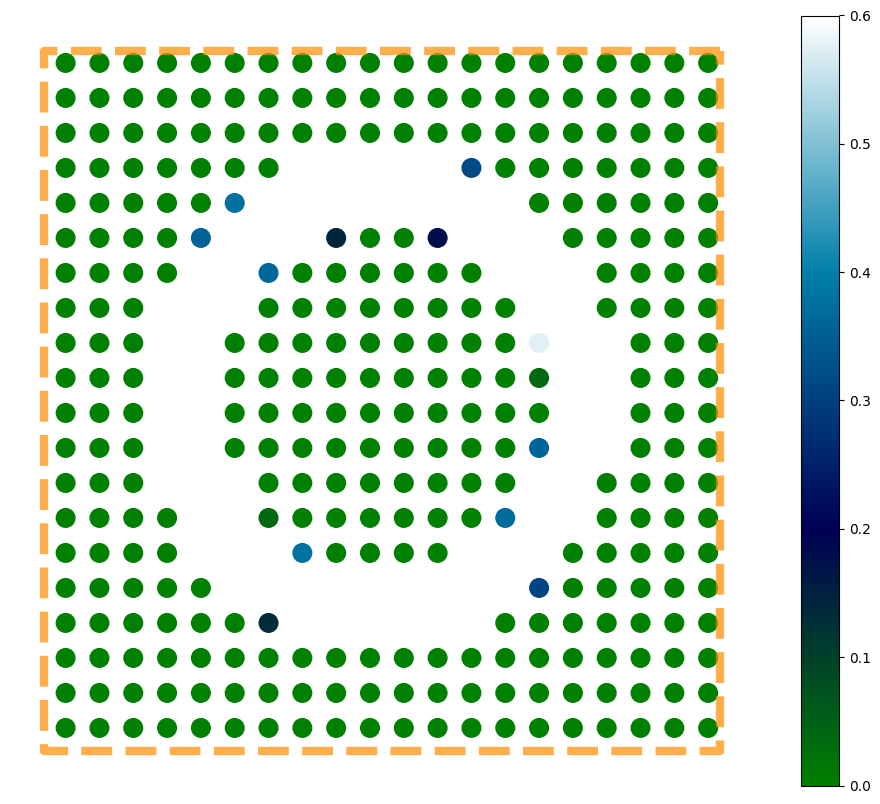

In [9]:
down_sampled=results_binocular_rivlary[:,3,6,0,8000::10] 
fig, ax = plt.subplots(1,1,  figsize=(12, 10))
norm = mcolors.Normalize(vmin=0, vmax=.6) 
sm = cm.ScalarMappable(cmap='ocean', norm=norm)
plt.colorbar(sm, ax=ax)
def animate(frames):

    ax.clear()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis('off')

    ax.scatter([i[0] for i in neural_masses], 
                [i[1] for i in neural_masses],
                c=down_sampled[:,frames],
                cmap='ocean',
                s=180, 
                vmax=0.2,
                vmin=0.1
                )
    ax.plot([i[0] for i in vertices_cortex]+[vertices_cortex[0][0]], 
            [i[1] for i in vertices_cortex]+[vertices_cortex[0][1]],
            color='darkorange',
            linewidth=6,
            linestyle='--',
            alpha=0.7)
    

    
    return 

anim = FuncAnimation(
    fig, 
    animate,
    frames=len(down_sampled[0,:]),
    interval=50, 
    repeat=False)

anim.save('Binocular_or1.mp4', 
          writer = 'ffmpeg', fps = 70)

#### Attentional waves in the presence of a flashing stimulus

In [4]:
dt        = 0.5      # in ms
T         = 8000       # in ms
nt        = int(T / dt)
start     = (5000 * 2)   # pulse on  (absolut time-steps)
stop      = (5100 * 2)   # pulse off (absolut time-steps)
nResponses = 6
ntheta     = 2
nLayers    = 24
aKernel    = np.array([[1, -1], [-1, 1]], dtype=np.float32)
distance_coef = 2
n_m, n, sigma, m, wh = 1, 2, 0.5, 2, 2
tau_s, tau_b, tau_a, tau_h = 6, 5, 2, 1500
b_0 = 0.5
sigma_a   = 0.2
go, gc, gr = 0.1, 0.0, 0.0
sigma_s   = 5.0
contrastR, contrastL = 0.8,0.8
coef_opo, coef_att   = 5, 5
inner_radius, outer_radius = 4.4, 6.0
ga = 0.1
W_rr = np.ones((1, 1))
c_attention = 10
tau_v1 = 4
tau_attention = 2
tau_adaptation = 1500
tau_opponency = 4
tau_recurrence = 10
tau_binocular = 4

In [5]:
midpoint, vertices_cortex, neural_masses, n_mass, distance_matrix, results, wo, wa, wc, wr, wr_local = brwmStim.cortical_surface_model(nt,nResponses,ntheta,nLayers,go,ga,gc,gr,sigma_s,distance_coef,coef_opo,coef_att,V1_area=2500, cortical_surface='square')
rf, visual_field_pos_neural_masses = brwmStim.make_pRFs(midpoint, neural_masses, n_mass)
inpu=brwmStim.prepare_gabor_input(4.4,6,nt,rf,contrast_values=np.array([contrastR,contrastR]),pulse_time=np.array([start,stop]), condition='normal')

In [6]:
input_const = inpu[216,0,1,0]
input_pulse = inpu[216,0,0,0]
inpu[:,:,:,:] = 0

pulse_list = [190, 169,170,171, 189, 191, 209, 210, 211]

frequency = 10
t_indices = np.arange(11000)  * 0.0005
wave = input_pulse * np.sin(2 * np.pi * frequency * t_indices)

for x in pulse_list:
    inpu[x, 0, 0, 3000:14000] = wave
    inpu[x, 1, 0, 3000:14000] = wave


inpu = inpu.astype(np.float32)

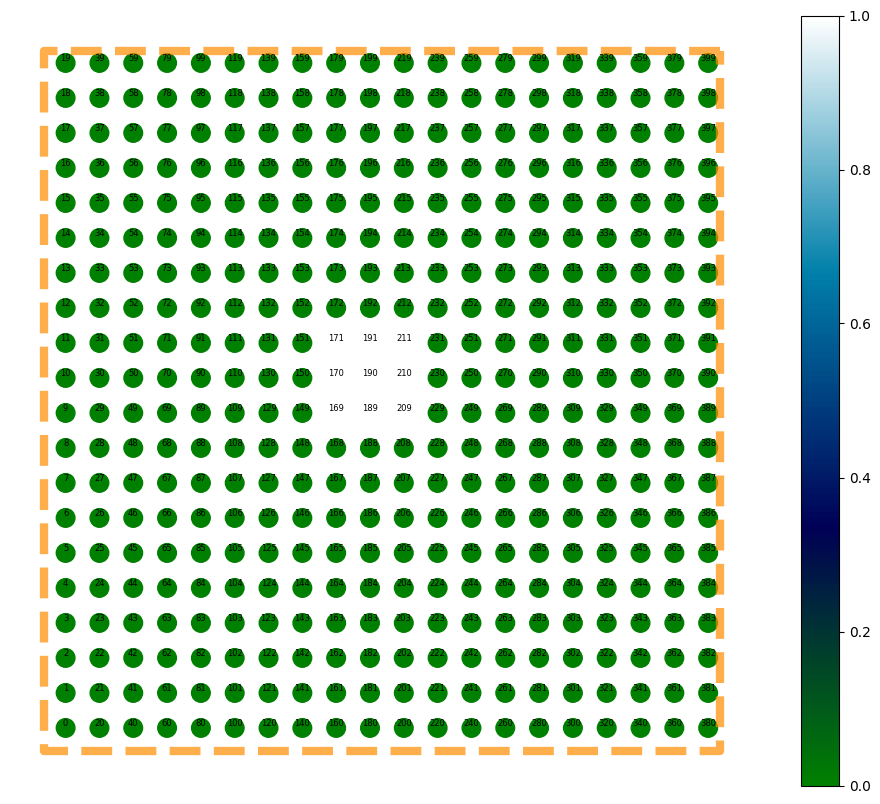

In [7]:
fig, ax = plt.subplots(1,1,  figsize=(12, 10))
ax.clear()
ax.set_xticks([])
ax.set_yticks([])
ax.axis('off')
down_sampled = inpu[:,0,0,3050]
# norm = mcolors.Normalize(vmin=0, vmax=.6) 
sm = cm.ScalarMappable(cmap='ocean')
plt.colorbar(sm, ax=ax)

ax.scatter([i[0] for i in neural_masses], 
                [i[1] for i in neural_masses],
                c=down_sampled[:],
                cmap='ocean',
                s=180, 
                vmax=0.2,
                vmin=0.1
                )

for k, mass in enumerate(neural_masses):
        ax.annotate(f'{k}', 
                    xy=(mass[0], mass[1]),
                     ha='center', va='bottom',
                    fontsize=6,
                    color='black')

ax.plot([i[0] for i in vertices_cortex]+[vertices_cortex[0][0]], 
            [i[1] for i in vertices_cortex]+[vertices_cortex[0][1]],
            color='darkorange',
            linewidth=6,
            linestyle='--',
            alpha=0.7)

In [8]:
results_attentional_waves=brwm_ORGaNICs.run_simulation( 
nt, 
n_mass,
dt,
ntheta,
n_m,
n,
sigma,
m,
wh,
tau_v1,
tau_attention,
tau_adaptation,
tau_opponency,
tau_recurrence,
tau_binocular,
sigma_a,
aKernel,
results, 
wo, 
wa,
inpu,
wc,
wr,
wr_local,
W_rr,
b_0,
c_attention)

/home/jjawale/For_the_repo/Travelling_waves/BinocularRivalryWavesORGaNICs_vers1.py:225: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'C', False, aligned=True))
  attention_rivalry_model_ORGaNICs(t, idx, dt, ntheta, n_m, n, sigma, m, wh,
/home/jjawale/For_the_repo/Travelling_waves/BinocularRivalryWavesORGaNICs_vers1.py:225: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'A', False, aligned=True), Array(float32, 1, 'C', False, aligned=True))
  attention_rivalry_model_ORGaNICs(t, idx, dt, ntheta, n_m, n, sigma, m, wh,
/home/jjawale/For_the_repo/Travelling_waves/BinocularRivalryWavesORGaNICs_vers1.py:225: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'C', False, aligned=True))
  attention_rivalry_model_ORGaNICs(t, idx, dt, ntheta, n_m, n, sigma, m, wh,
/hom

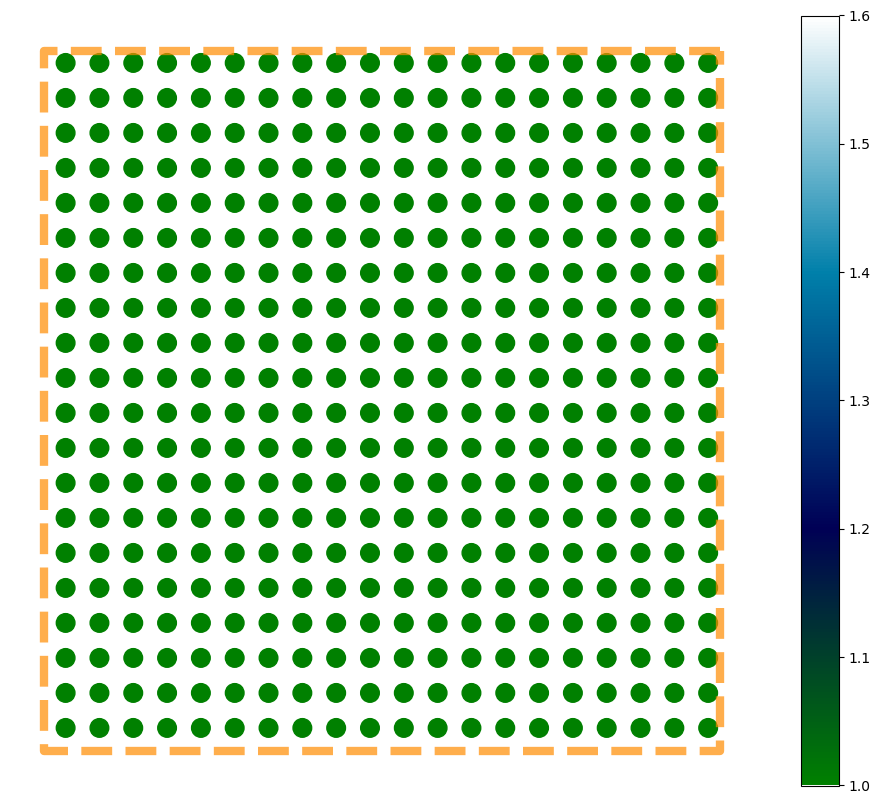

In [9]:
down_sampled=results_attentional_waves[:,3,2,0,0:8000:10] 
fig, ax = plt.subplots(1,1,  figsize=(12, 10))
norm = mcolors.Normalize(vmin=1, vmax=1.6)  # ← updated
sm = cm.ScalarMappable(cmap='ocean', norm=norm)
plt.colorbar(sm, ax=ax)
def animate(frames):

    ax.clear()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis('off')

    ax.scatter([i[0] for i in neural_masses], 
                [i[1] for i in neural_masses],
                c=down_sampled[:,frames],
                cmap='ocean',
                s=180, 
                vmax=1.6,  # ← updated
                vmin=1.0   # ← updated
                )
    ax.plot([i[0] for i in vertices_cortex]+[vertices_cortex[0][0]], 
            [i[1] for i in vertices_cortex]+[vertices_cortex[0][1]],
            color='darkorange',
            linewidth=6,
            linestyle='--',
            alpha=0.7)
    
    return 

anim = FuncAnimation(
    fig, 
    animate,
    frames=len(down_sampled[0,:]),
    interval=50, 
    repeat=False)

anim.save('Attentional_waves.mp4', 
          writer = 'ffmpeg', fps = 70)